In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

RESULTS_PATH = Path('SI_results') / 'FigS5.csv'
TABLE_PATH = Path('SI_results') / 'Plot_FigS5.csv'
OUTPUT_DIR = Path('SI_Figures')
FIGURE_PATH = OUTPUT_DIR / 'FigS5.tiff'

RESULTS_PATH, FIGURE_PATH

(WindowsPath('SI_results/FigS5.csv'), WindowsPath('SI_Figures/FigS5.tiff'))

In [2]:
# ===============================
# Global journal-style settings
# ===============================
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 14,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.linewidth': 2,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'xtick.major.size': 6,
    'ytick.major.size': 6,
    'xtick.major.width': 2.0,
    'ytick.major.width': 2.0,
    'ytick.minor.visible': False,
    'xtick.minor.visible': False,
    'lines.solid_capstyle': 'round',
})


def hex_to_rgba(hex_color, alpha=1.0):
    hex_color = hex_color.lstrip('#')
    r, g, b = [int(hex_color[i:i + 2], 16) / 255 for i in (0, 2, 4)]
    return (r, g, b, alpha)


COLORS = {
    'axis': '#1F1F1F',
    'grid': '#D4D4D4',
}

LINE_COLORS_TOP_TO_BOTTOM = [
    '#2171AE',
    hex_to_rgba('#2171AE', 0.55),
    '#DA4048',
    hex_to_rgba('#DA4048', 0.45),
    hex_to_rgba('#DA4048', 0.25),
]

In [3]:
raw = pd.read_csv(RESULTS_PATH)
raw['Zvar'] = raw['Zvar'].replace({'Climate_moderat': 'Climate_moderate'})

definition_map = {
    ('Grade_8', 'Climate'): 'Top 8%, 35$^\\circ$C / -15$^\\circ$C',
    ('Grade', 'Climate'): 'Baseline: Top 10%, 35$^\\circ$C / -15$^\\circ$C',
    ('Grade_12', 'Climate'): 'Top 12%, 35$^\\circ$C / -15$^\\circ$C',
    ('Grade', 'Climate_l'): 'Top 10%, 33$^\\circ$C / -13$^\\circ$C',
    ('Grade', 'Climate_h'): 'Top 10%, 37$^\\circ$C / -17$^\\circ$C',
}

outcome_map = {
    'y11': 'Workload',
    'y12': 'Overload probability',
    'y22': 'Heat exhaustion',
    'y23': 'Heatstroke',
    'y33': 'Mild cold hypothermia',
    'y34': 'Moderate cold hypothermia',
}

records = []
for depvar, outcome in outcome_map.items():
    for (tier, climate), definition in definition_map.items():
        match = raw.loc[
            raw['depvar'].eq(depvar) & raw['Yvar'].eq(tier) & raw['Zvar'].eq(climate)
        ]
        if match.empty:
            raise KeyError(f'Missing estimate for depvar={depvar}, Yvar={tier}, Zvar={climate}')
        row = match.iloc[0]
        records.append({
            'depvar': depvar,
            'outcome': outcome,
            'definition': definition,
            'coef': row['coef'],
            'se': row['se'],
            'pval': row['pval'],
            'lower': row['coef'] - 1.96 * row['se'],
            'upper': row['coef'] + 1.96 * row['se'],
        })

df = pd.DataFrame(records)

definition_order = list(definition_map.values())
panel_order = list(outcome_map.values())
df['definition'] = pd.Categorical(df['definition'], categories=definition_order, ordered=True)
df['outcome'] = pd.Categorical(df['outcome'], categories=panel_order, ordered=True)

TABLE_PATH.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(TABLE_PATH, index=False, encoding='utf-8-sig')

In [4]:
def symmetric_limits(values, lower, upper, pad=0.18):
    xmin = min(values.min(), lower.min(), 0)
    xmax = max(values.max(), upper.max(), 0)
    width = xmax - xmin
    if width <= 0:
        width = 1
    return xmin - pad * width, xmax + pad * width


x_limits = {}
for outcome in panel_order:
    sub = df.loc[df['outcome'].eq(outcome)]
    x_limits[outcome] = symmetric_limits(sub['coef'], sub['lower'], sub['upper'])

x_limits

{'Workload': (-1.716479477646807, 11.252476575684625),
 'Overload probability': (-4.415323943143177, 28.944901405049713),
 'Heat exhaustion': (-1.1201437924110258, 7.343164861361169),
 'Heatstroke': (-0.8232277755572243, 5.396715417541803),
 'Mild cold hypothermia': (-1.8263987397339756, 11.973058404922728),
 'Moderate cold hypothermia': (-0.3089003486068541, 2.02501339642271)}

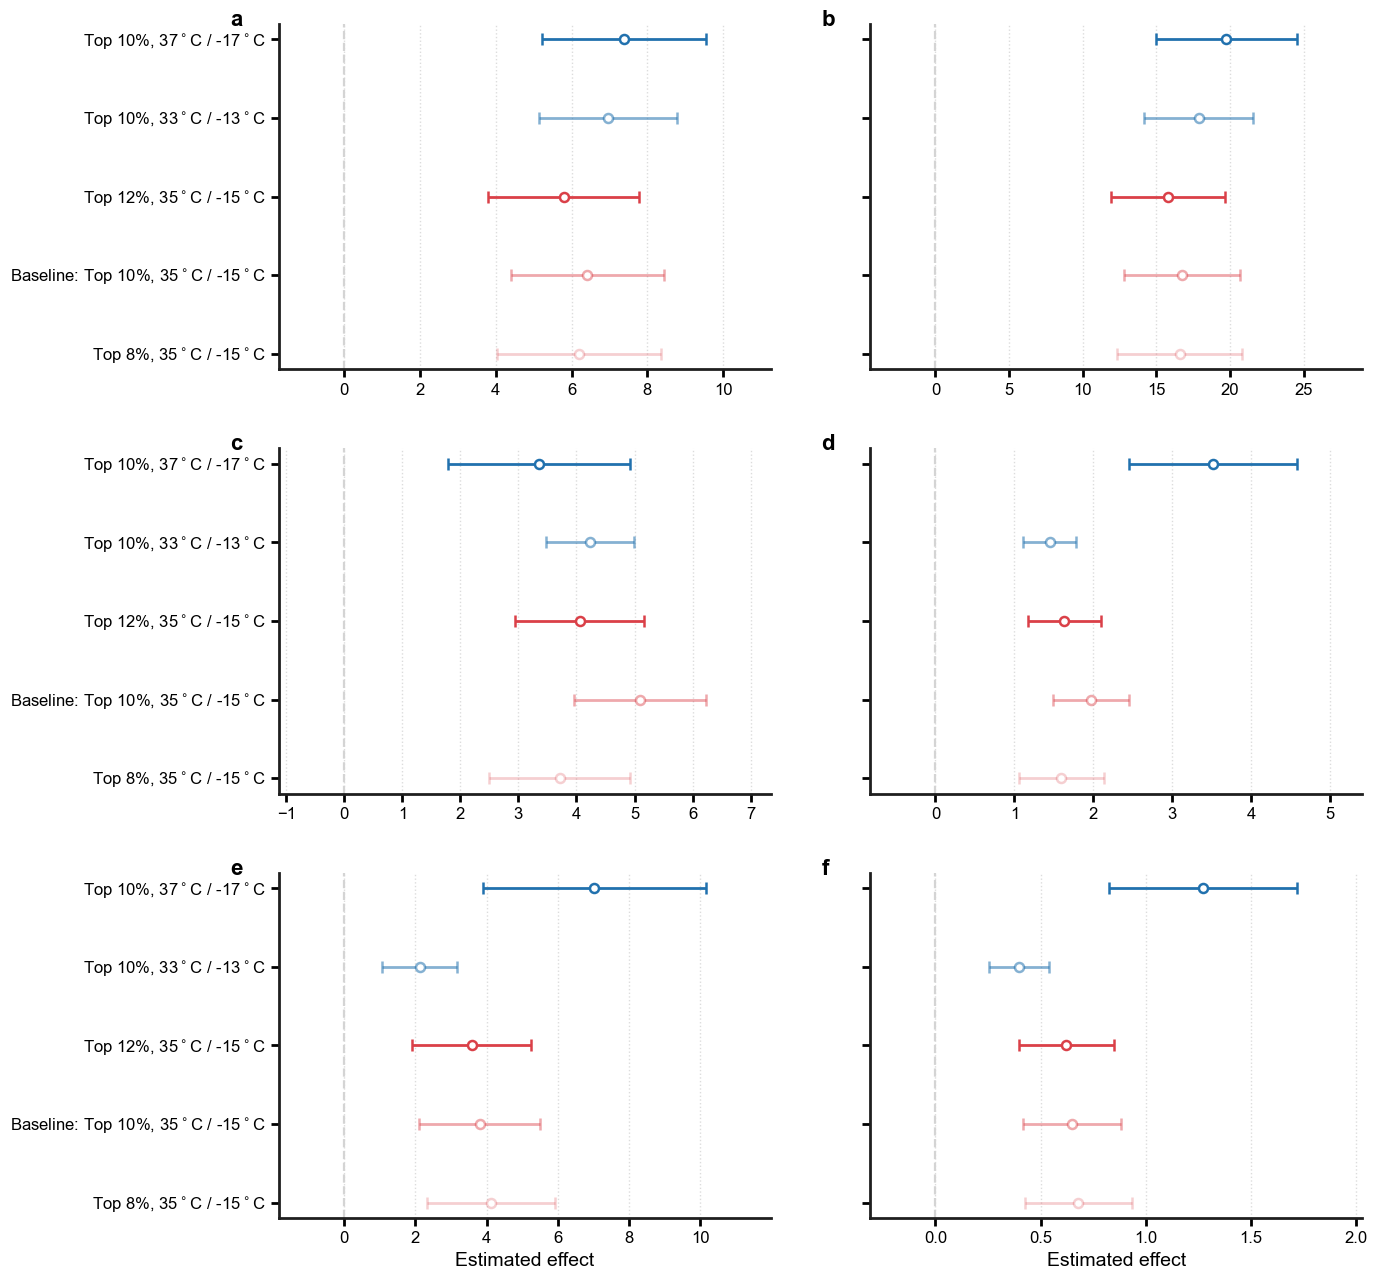

Saved figure: SI_Figures\FigS5.tiff
Saved plotting table: SI_results\Plot_FigS5.csv
Rows plotted: 30
Definitions plotted:
  - Top 8%, 35$^\circ$C / -15$^\circ$C
  - Baseline: Top 10%, 35$^\circ$C / -15$^\circ$C
  - Top 12%, 35$^\circ$C / -15$^\circ$C
  - Top 10%, 33$^\circ$C / -13$^\circ$C
  - Top 10%, 37$^\circ$C / -17$^\circ$C


WindowsPath('SI_Figures/FigS5.tiff')

In [5]:
fig, axes = plt.subplots(3, 2, figsize=(14, 13), sharey=True)
axes = axes.flatten()

for idx, (ax, outcome) in enumerate(zip(axes, panel_order)):
    sub = df[df['outcome'].eq(outcome)].sort_values('definition')
    y = list(range(len(sub)))
    coef = sub['coef'].to_numpy()
    lower = sub['lower'].to_numpy()
    upper = sub['upper'].to_numpy()

    row_colors = list(reversed(LINE_COLORS_TOP_TO_BOTTOM))
    for yi, ci, lo, hi, color in zip(y, coef, lower, upper, row_colors):
        ax.errorbar(
            ci,
            yi,
            xerr=[[ci - lo], [hi - ci]],
            fmt='o',
            color=color,
            ecolor=color,
            markerfacecolor='white',
            markeredgecolor=color,
            markeredgewidth=1.8,
            markersize=6.5,
            elinewidth=2.0,
            capsize=4,
            capthick=1.6,
            zorder=3,
        )

    ax.axvline(0, color=COLORS['grid'], linestyle='--', linewidth=1.6, zorder=1)
    ax.grid(axis='x', color=COLORS['grid'], linestyle=':', linewidth=1.0, alpha=0.8, zorder=0)

    ax.set_yticks(y)
    ax.set_yticklabels(sub['definition'])
    ax.invert_yaxis()
    ax.set_xlim(*x_limits[outcome])

    ax.text(
        -0.10,
        1.04,
        chr(97 + idx),
        transform=ax.transAxes,
        fontsize=16,
        fontweight='bold',
        va='top',
        ha='left',
    )

    ax.tick_params(axis='both', which='major', width=2.0, length=6)
    for spine in ['left', 'bottom']:
        ax.spines[spine].set_color(COLORS['axis'])
        ax.spines[spine].set_linewidth(2.0)

for ax in axes[-2:]:
    ax.set_xlabel('Estimated effect')

fig.tight_layout(w_pad=2.6, h_pad=2.0)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIGURE_PATH, format='tiff', dpi=600, bbox_inches='tight')
plt.show()

print(f'Saved figure: {FIGURE_PATH}')
print(f'Saved plotting table: {TABLE_PATH}')
print(f'Rows plotted: {len(df)}')
print('Definitions plotted:')
for definition in definition_order:
    print(f'  - {definition}')

FIGURE_PATH